# Nested CV model comparison for body mass

This notebook compares the nested-CV MLP avgGRM runs with optimized ridge variants and the BPCRR full-source baseline. It now includes the density-ratio weighted ridge run from `outputs/nested_cv/ridge/ridge_importance_weighted_nested_results.json`.

Notes:
- The JSON files store the winning configuration for each outer fold, not the complete Optuna trial history.
- The chosen-trial sections below summarize those fold-level winners and should be read as selected-model diagnostics.
- The performance comparison uses the shared 16 leave-one-island-out targets so the rows line up across MLP, ridge, and BPCRR.


## Setup

In [1]:
from pathlib import Path
import importlib
import sys

from IPython.display import display

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = next(
    (
        candidate
        for candidate in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]
        if (candidate / "src").exists() and (candidate / "outputs").exists()
    ),
    NOTEBOOK_DIR,
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import src.mlp_avggrm_viz_report as viz_report
viz_report = importlib.reload(viz_report)

build_full_baseline_comparison = viz_report.build_full_baseline_comparison
build_full_baseline_summary = viz_report.build_full_baseline_summary
build_full_heatmap_df = viz_report.build_full_heatmap_df
build_full_winner_counts = viz_report.build_full_winner_counts
build_importance_weighted_ridge_overview = viz_report.build_importance_weighted_ridge_overview
build_importance_weighted_ridge_scheme_summary = viz_report.build_importance_weighted_ridge_scheme_summary
build_importance_weighted_ridge_winner_table = viz_report.build_importance_weighted_ridge_winner_table
build_model_summary = viz_report.build_model_summary
build_ridge_nested_overview = viz_report.build_ridge_nested_overview
build_ridge_nested_scheme_summary = viz_report.build_ridge_nested_scheme_summary
build_ridge_nested_winner_table = viz_report.build_ridge_nested_winner_table
build_scheme_summary = viz_report.build_scheme_summary
build_winner_table = viz_report.build_winner_table
plot_full_baseline_comparison = viz_report.plot_full_baseline_comparison
plot_full_baseline_heatmap_and_winners = viz_report.plot_full_baseline_heatmap_and_winners
plot_importance_weighted_ridge_selection_summary = viz_report.plot_importance_weighted_ridge_selection_summary
plot_mlp_preference_grid = viz_report.plot_mlp_preference_grid
plot_mlp_selection_summary = viz_report.plot_mlp_selection_summary
plot_ridge_nested_selection_summary = viz_report.plot_ridge_nested_selection_summary
prepare_report_data = viz_report.prepare_report_data

report = prepare_report_data(PROJECT_ROOT)


## Data included

The first table is a compact overview of the nested-CV and full-source baseline results shown in this notebook. Top-k reference runs are still available in the helper module, but the old `k=1500` plot is intentionally omitted here to keep the comparison focused.


In [2]:
summary = build_model_summary(report)
summary = summary.loc[~summary["comparison_group"].str.startswith("Top-k")]
display(summary.round(3))

print(f"Shared islands in the main comparison: {len(report['full_baseline_islands'])}")
print(", ".join(report["island_name_map"].get(i, str(i)) for i in report["full_baseline_islands"]))
print()
print("Nested-CV ridge result files:")
print(f"avgGRM ridge: {report['ridge_nested_path'].relative_to(PROJECT_ROOT)}")
print(f"density-ratio ridge: {report['ridge_importance_weighted_path'].relative_to(PROJECT_ROOT)}")


,comparison_group,label,n_islands,mean_corr,median_corr,std_corr
0,MLP weighted full,MLP avgGRM weighted,16,0.169,0.166,0.084
1,MLP weighted full (smart inner top-5),MLP avgGRM weighted (smart 5 inner islands),16,0.164,0.151,0.089
2,MLP weighted full (smart inner top-3),MLP avgGRM weighted (smart 3 inner islands),16,0.134,0.114,0.125
3,Full baselines (16 islands),Ridge (avgGRM nested CV),16,0.182,0.175,0.105
4,Full baselines (16 islands),BPCRR | full_source_unweighted,16,0.180,0.177,0.097
5,Full baselines (16 islands),Ridge (PCA) | full_source_unweighted,16,0.167,0.147,0.126
6,Full baselines (16 islands),Ridge (avgGRM) | full_source_unweighted,16,0.167,0.147,0.126
7,Full baselines (16 islands),Ridge (density-ratio nested CV),16,0.158,0.168,0.095


Shared islands in the main comparison: 16
Nesøy, Myken, Træna, Selvær, Gjerøy, Hestmannøy, Indre Kvarøy, Onøy og Lurøy, Lovund, Sleneset, Aldra, Southern 1, Southern 2, Southern 3, Southern 4, Southern 5

Nested-CV ridge result files:
avgGRM ridge: outputs\nested_cv\ridge_avggrm_weighted_nested_results.json
density-ratio ridge: outputs\nested_cv\ridge\ridge_importance_weighted_nested_results.json


## Outer-fold performance

### Shared 16-island comparison

This plot compares the outer-fold Pearson correlations on the same target islands. The diamond marker gives the model mean; individual black points are the island-level results.


,model_label,mean_corr,median_corr,std_corr,n
0,Ridge (avgGRM nested CV),0.182,0.175,0.105,16
1,BPCRR | full_source_unweighted,0.180,0.177,0.097,16
2,MLP avgGRM weighted,0.169,0.166,0.084,16
3,Ridge (PCA) | full_source_unweighted,0.167,0.147,0.126,16
4,Ridge (avgGRM) | full_source_unweighted,0.167,0.147,0.126,16
5,MLP avgGRM weighted (smart 5 inner islands),0.164,0.151,0.089,16
6,Ridge (density-ratio nested CV),0.158,0.168,0.095,16
7,MLP avgGRM weighted (smart 3 inner islands),0.134,0.114,0.125,16


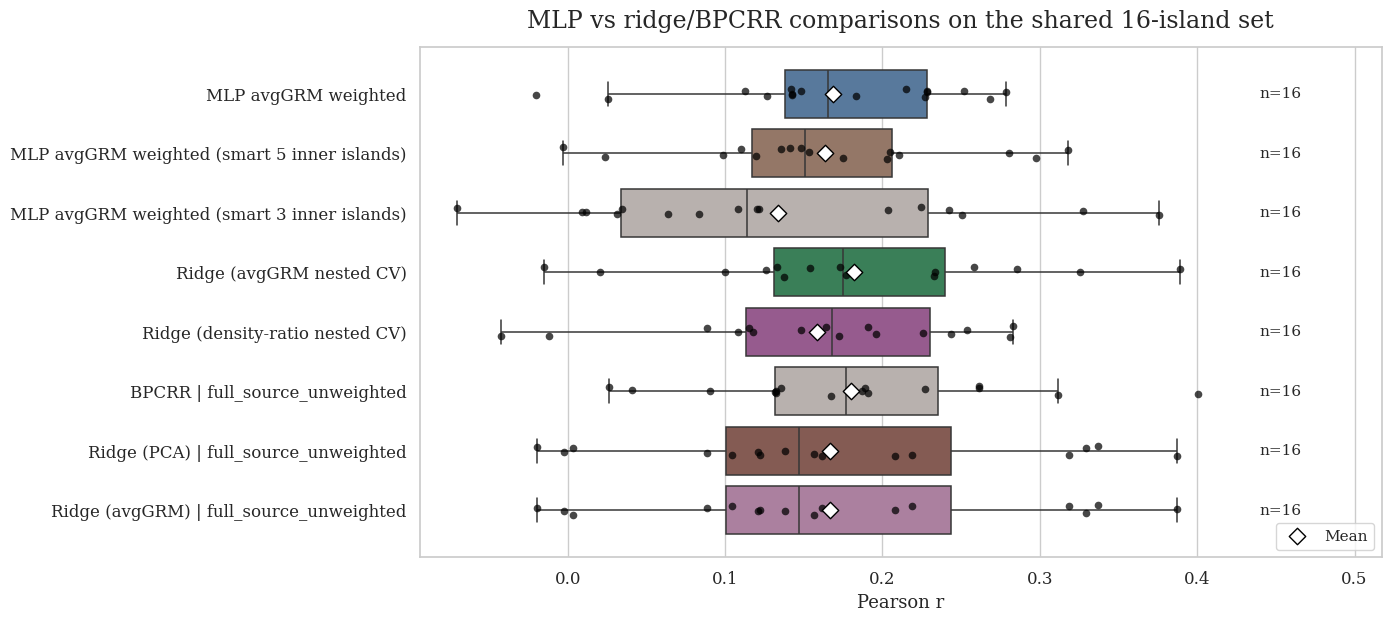

(<Figure size 1380x610 with 1 Axes>,
 <Axes: title={'center': 'MLP vs ridge/BPCRR comparisons on the shared 16-island set'}, xlabel='Pearson r'>)

In [3]:
display(build_full_baseline_summary(report).round(3))
plot_full_baseline_comparison(report)


### Island-level winners

The heatmap gives the per-island Pearson `r` values, and the bar plot counts which model is best on each target island.


model_label,BPCRR | full_source_unweighted,MLP avgGRM weighted,MLP avgGRM weighted (smart 3 inner islands),MLP avgGRM weighted (smart 5 inner islands),Ridge (PCA) | full_source_unweighted,Ridge (avgGRM nested CV),Ridge (avgGRM) | full_source_unweighted,Ridge (density-ratio nested CV)
Nesøy,0.311,0.229,0.120,0.136,0.208,0.233,0.208,0.226
Myken,0.167,0.268,0.328,0.298,0.337,0.325,0.337,0.283
Træna,0.261,0.183,0.225,0.141,0.156,0.183,0.156,0.148
Selvær,0.189,0.228,0.251,0.203,0.219,0.233,0.219,0.196
Gjerøy,0.091,0.112,0.108,0.148,0.088,0.100,0.088,0.088
Hestmannøy,0.132,0.142,0.121,0.153,0.138,0.173,0.138,0.172
Indre Kvarøy,0.262,0.227,0.242,0.205,0.319,0.258,0.319,0.254
Onøy og Lurøy,0.227,-0.020,0.009,-0.003,-0.003,-0.015,-0.003,-0.012
Lovund,0.400,0.279,0.376,0.318,0.387,0.389,0.387,0.281
Sleneset,0.187,0.143,0.064,0.120,0.162,0.154,0.162,0.191


,model_label,wins
0,MLP avgGRM weighted,1
1,MLP avgGRM weighted (smart 5 inner islands),2
2,MLP avgGRM weighted (smart 3 inner islands),1
3,Ridge (avgGRM nested CV),2
4,Ridge (density-ratio nested CV),1
5,BPCRR | full_source_unweighted,6
6,Ridge (PCA) | full_source_unweighted,3
7,Ridge (avgGRM) | full_source_unweighted,0


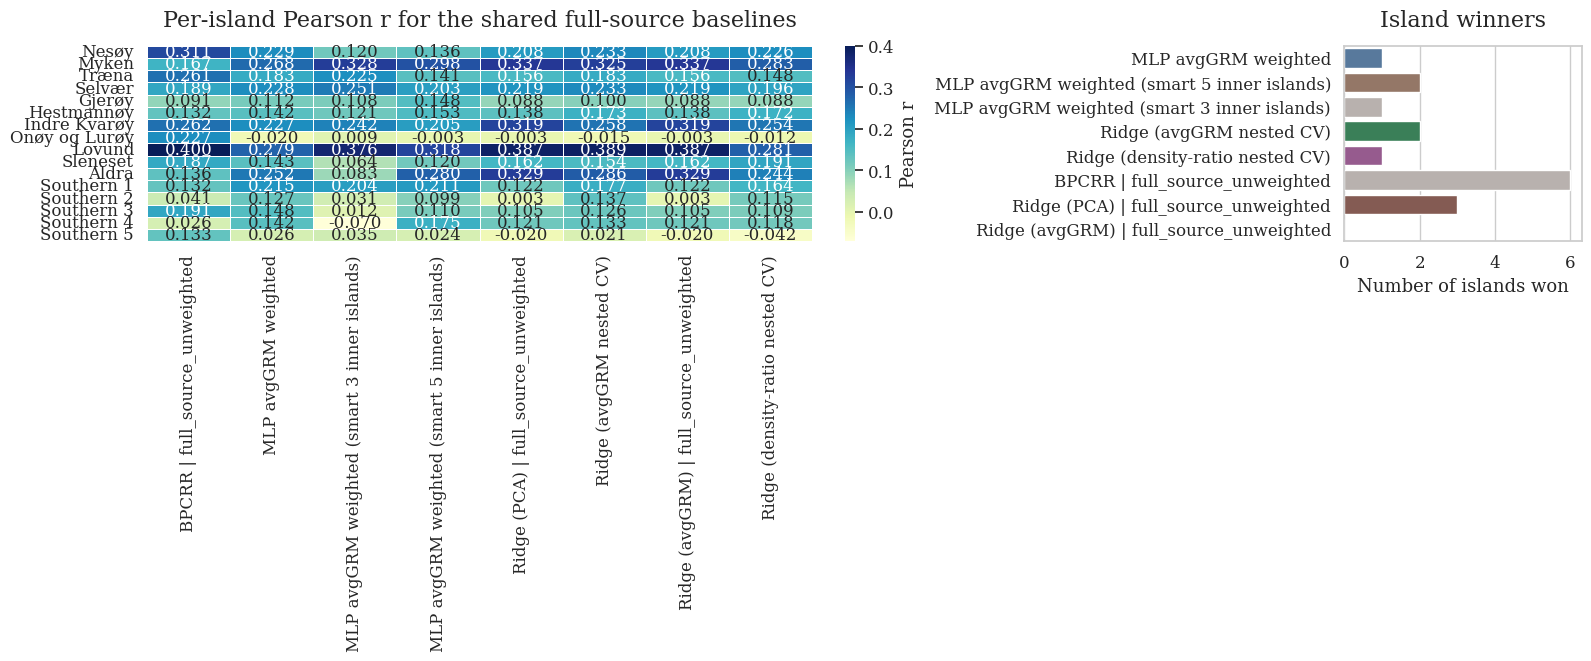

(<Figure size 1580x650 with 3 Axes>,
 array([<Axes: title={'center': 'Per-island Pearson r for the shared full-source baselines'}>,
        <Axes: title={'center': 'Island winners'}, xlabel='Number of islands won'>],
       dtype=object))

In [4]:
display(build_full_heatmap_df(report).round(3))
display(build_full_winner_counts(report))
plot_full_baseline_heatmap_and_winners(report)


## Chosen-trial diagnostics

These sections describe the winning trial selected inside each outer fold. Because the complete Optuna histories are not stored in the merged JSON files, these diagnostics answer: *what did nested CV choose when it had to pick one configuration for each held-out island?*


### MLP avgGRM winners

The MLP diagnostics summarize the original weighted MLP run, including which weighting schemes and architecture choices won across folds.


,weight_scheme,count,mean_outer_r,median_outer_r
0,minmax,7,0.150,0.142
1,exponential,4,0.201,0.197
2,top-heavy,3,0.161,0.228
3,linear,2,0.182,0.182


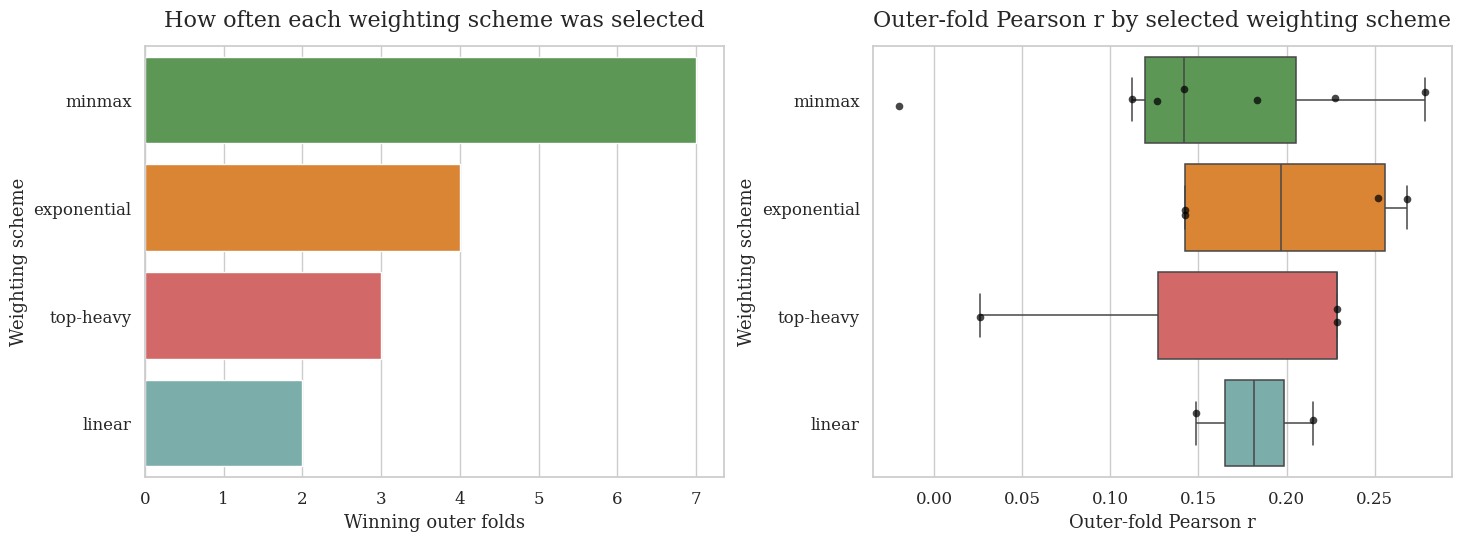

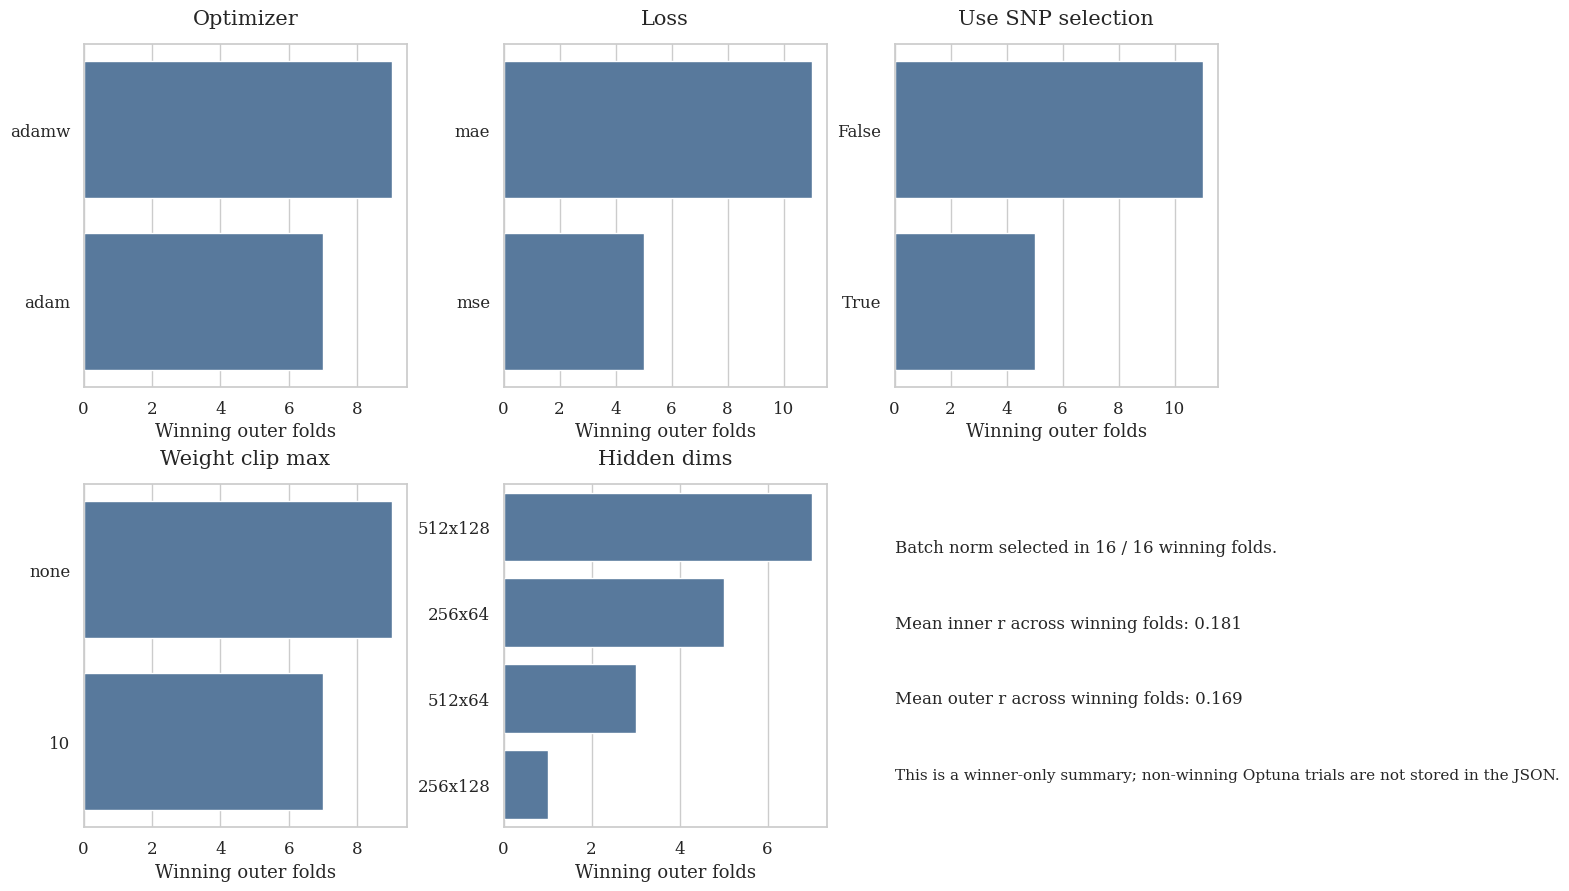

,fold,target_island_name,corr,mean_inner_r,weight_scheme,weighting_detail,optimizer,loss,use_snp_selection_label,hidden_dims,epochs,num_snps
0,1,Nesøy,0.229,0.179,top-heavy,"top_frac=0.07, low=0.92, high=1.35",adamw,mae,True,512x128,232,43628.0
1,2,Myken,0.268,0.179,exponential,beta=3.54,adamw,mae,False,512x128,140,NaN
2,3,Træna,0.183,0.185,minmax,"eps=0.193, clip=10",adamw,mse,False,512x64,134,NaN
3,4,Selvær,0.228,0.180,top-heavy,"top_frac=0.07, low=0.95, high=1.62",adam,mae,False,512x128,55,NaN
4,5,Gjerøy,0.112,0.177,minmax,"eps=0.077, clip=10",adam,mse,True,256x64,215,36890.0
5,6,Hestmannøy,0.142,0.168,exponential,beta=7.87,adamw,mae,False,256x64,65,NaN
6,7,Indre Kvarøy,0.227,0.179,minmax,"eps=0.057, clip=10",adam,mse,True,256x128,153,7294.0
7,8,Onøy og Lurøy,-0.020,0.205,minmax,"eps=0.087, clip=none",adam,mae,False,256x64,243,NaN
8,9,Lovund,0.279,0.164,minmax,"eps=0.196, clip=10",adamw,mse,False,512x128,57,NaN
9,10,Sleneset,0.143,0.179,exponential,beta=7.46,adamw,mae,False,256x64,52,NaN


In [5]:
display(build_scheme_summary(report).round(3))
plot_mlp_selection_summary(report)
plot_mlp_preference_grid(report)
display(build_winner_table(report).round(3))


### avgGRM ridge winners

This is the optimized nested-CV ridge run using avgGRM-based weighting choices.


,model_label,n_folds,n_islands,mean_inner_r,mean_outer_r,median_outer_r,alpha_median,alpha_geom_mean,alpha_min,alpha_max,snp_selection_count,snp_selection_rate,median_num_snps_when_selected,most_common_weight_scheme
0,Ridge (avgGRM nested CV),16,16,0.191,0.182,0.175,409892.122,404560.103,103198.773,712465.904,7,0.438,41479.0,exponential


,weight_scheme,count,mean_outer_r,median_outer_r,mean_inner_r,median_alpha,snp_selection_count
0,exponential,9,0.143,0.137,0.194,409602.664,4
1,minmax,4,0.259,0.246,0.183,508444.262,1
2,linear,3,0.198,0.183,0.191,258207.220,2


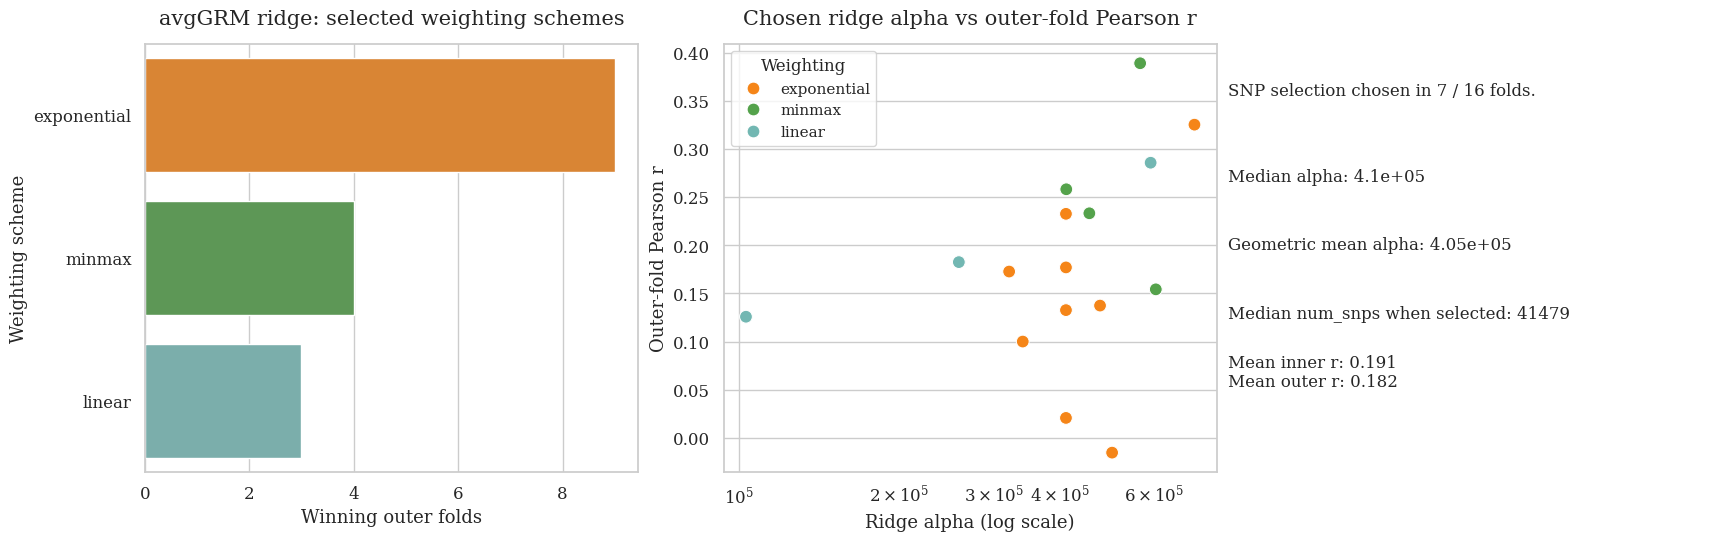

,fold,target_island_name,corr,mean_inner_r,alpha,weight_scheme,weighting_detail,use_snp_selection_label,num_snps
0,1,Nesøy,0.233,0.190,453040.366,minmax,"eps=0.045, clip=none",False,NaN
1,2,Myken,0.325,0.185,712465.904,exponential,beta=4.52,True,10582.0
2,3,Træna,0.183,0.195,258207.220,linear,"min=0.48, max=3.27",True,50216.0
3,4,Selvær,0.233,0.187,409602.664,exponential,beta=1.98,False,NaN
4,5,Gjerøy,0.100,0.201,340032.907,exponential,beta=2.10,True,30095.0
5,6,Hestmannøy,0.173,0.177,320655.599,exponential,beta=2.46,True,44655.0
6,7,Indre Kvarøy,0.258,0.181,410181.580,minmax,"eps=0.022, clip=10",True,55068.0
7,8,Onøy og Lurøy,-0.015,0.214,499681.489,exponential,beta=2.26,False,NaN
8,9,Lovund,0.389,0.170,563848.159,minmax,"eps=0.045, clip=none",False,NaN
9,10,Sleneset,0.154,0.191,603197.909,minmax,"eps=0.000, clip=none",False,NaN


In [6]:
if report["ridge_nested_df"].empty:
    print("No optimized avgGRM nested-CV ridge results were found.")
else:
    display(build_ridge_nested_overview(report).round(3))
    display(build_ridge_nested_scheme_summary(report).round(3))
    plot_ridge_nested_selection_summary(report)
    display(build_ridge_nested_winner_table(report).round(3))


### Density-ratio ridge winners

This section adds the newly completed density-ratio weighted ridge run. For `pc_logistic` winners, the table includes the selected PCA/logistic settings and the effective sample size diagnostics stored by the run.


,model_label,n_folds,n_islands,mean_inner_r,mean_outer_r,median_outer_r,alpha_median,alpha_geom_mean,alpha_min,alpha_max,snp_selection_count,snp_selection_rate,median_num_snps_when_selected,most_common_weight_scheme,median_effective_sample_size
0,Ridge (density-ratio nested CV),16,16,0.181,0.158,0.168,157589.716,105672.871,4084.142,342580.5,7,0.438,33920.0,uniform,5255.5


,weight_scheme,count,mean_outer_r,median_outer_r,mean_inner_r,median_alpha,snp_selection_count,median_effective_sample_size,median_n_components,median_logistic_c
0,uniform,13,0.140,0.164,0.183,161119.910,7,5341.000,NaN,NaN
1,pc_logistic,3,0.237,0.281,0.171,23354.019,0,673.735,10.0,1.426


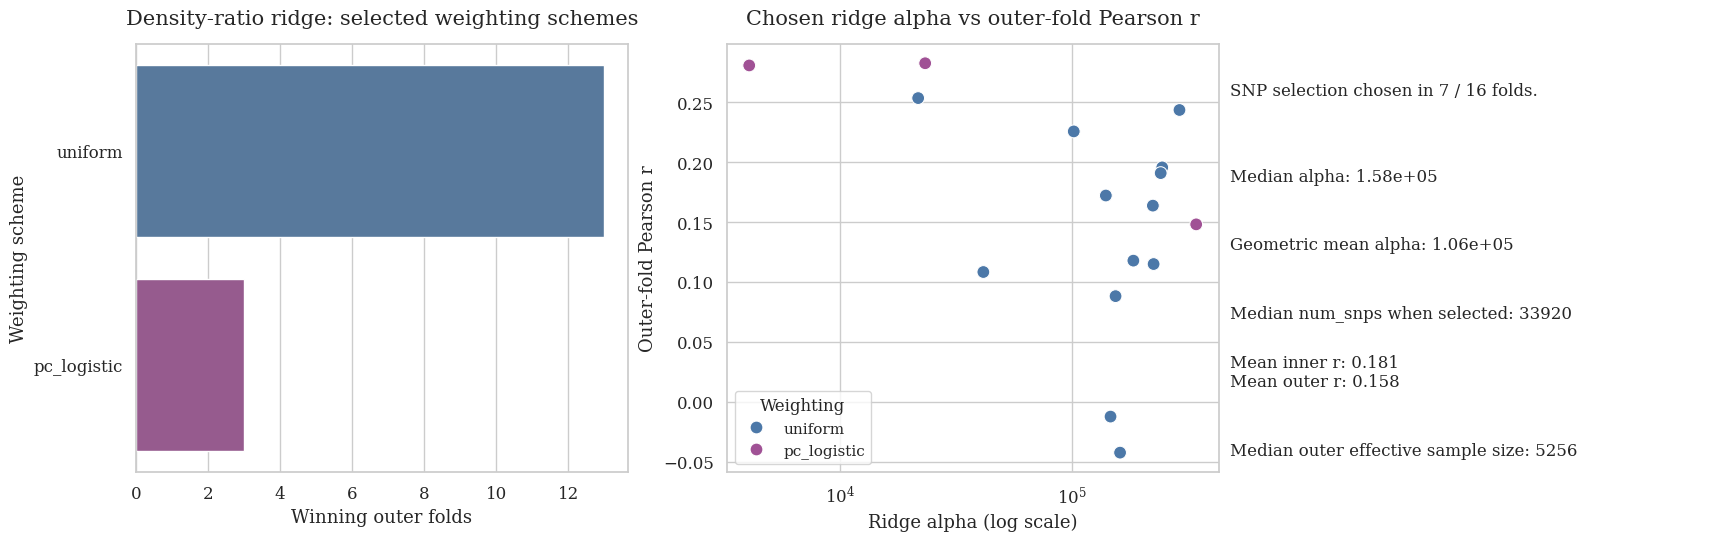

,fold,target_island_name,corr,mean_inner_r,alpha,weight_scheme,weighting_detail,use_snp_selection_label,num_snps,effective_sample_size,mean_inner_effective_sample_size,weight_n_components,weight_logistic_c,weight_pca_fit
0,1,Nesøy,0.226,0.181,101812.814,uniform,uniform,True,31823.0,5578.000,5206.133,NaN,NaN,NaN
1,2,Myken,0.283,0.166,23354.019,pc_logistic,"PCs=10, C=3.9, fit=combined, clip=25",False,NaN,471.686,298.184,10.0,3.899,combined
2,3,Træna,0.148,0.186,342580.500,pc_logistic,"PCs=5, C=1.4, fit=source, clip=5",False,NaN,3135.913,3051.889,5.0,1.426,source
3,4,Selvær,0.196,0.178,244681.190,uniform,uniform,True,34369.0,5503.000,5136.133,NaN,NaN,NaN
4,5,Gjerøy,0.088,0.195,154059.523,uniform,uniform,True,33920.0,5139.000,4796.400,NaN,NaN,NaN
5,6,Hestmannøy,0.172,0.170,139933.601,uniform,uniform,True,44455.0,4619.000,4311.067,NaN,NaN,NaN
6,7,Indre Kvarøy,0.254,0.173,21785.798,uniform,uniform,True,7961.0,5341.000,4984.933,NaN,NaN,NaN
7,8,Onøy og Lurøy,-0.012,0.202,146586.053,uniform,uniform,False,NaN,5438.000,5075.467,NaN,NaN,NaN
8,9,Lovund,0.281,0.160,4084.142,pc_logistic,"PCs=10, C=0.078, fit=combined",False,NaN,673.735,152.555,10.0,0.078,combined
9,10,Sleneset,0.191,0.177,240978.817,uniform,uniform,True,36247.0,5531.000,5162.267,NaN,NaN,NaN


In [7]:
if report["ridge_importance_weighted_df"].empty:
    print("No density-ratio nested-CV ridge results were found.")
else:
    display(build_importance_weighted_ridge_overview(report).round(3))
    display(build_importance_weighted_ridge_scheme_summary(report).round(3))
    plot_importance_weighted_ridge_selection_summary(report)
    display(build_importance_weighted_ridge_winner_table(report).round(3))
